In [1]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import linkage, dendrogram


This notebook includes the following,
1. Definition of Supervised and Unsupervised Learning and Clustring Types
2. Definition and usage of KMeans
3. Determining the optimum number of clusters (K) in a certain dataset.
4. Some dendrogram examples to explain hierarchical clustering better.

Let's get started.

# 1. Relevant Definitions About the Topic
1. Supervised Learning: In supervised learning, we use labeled data sets to train algorithms and make predictions.[[1]](https://www.ibm.com/cloud/learn/supervised-learning) It can be separated into two different subtitles: Classification and Regression. In a classification problem, the machine learning algorithm is trained to predict a specific class. In a regression problem, the machine learning algorithm is trained to predict a numeric value (not a class). 
2. Unsupervised Learning: In unsupervised learning, we use machine learning algorithms to analyze and cluster unlabeled datasets. [[2]](https://www.ibm.com/cloud/learn/unsupervised-learning)
3. Clustering: It is a data mining technique that is used for grouping the unlabeled data based on their similarities and differences. Clustring is used in unsupervised learning. The clustering process can be done in several ways like exclusive, overlapping, hierarchical, and probabilistic.
 * Exclusive Clustering: In this type of clustering a data point can only belong to one specific cluster.
 * Overlapping Clustering: It is the reverse of exclusive clustering. In other words, a data point can belong to more than one cluster.
 * Hierarchical Clustering: Data points are grouped based on their similarities. Then formed clusters are grouped in the same fashion iteratively. It can be better understood in dendrograms. (Appendix)
 * Probabilistic Clustering: In probabilistic clustering data points are clustered based on the likelihood that they belong to a particular distribution. Principal component analysis (PCA), Singular value decomposition (SVD), and Autoencoders are examples of probabilistic clustering. 
4. K-Means: In K-Means we cluster the dataset to K different clusters. A center point is assigned to each of these clusters. The location of the center point is found by minimizing the sum of the distance between each data point and cluster center.

# 2.K-Means 
First, we apply the K-Means method to Iris dataset, then plot the clusters in 2 and 3D environments respectively.

In [2]:
data=pd.read_csv('../input/iris/Iris.csv')

In [3]:
work_data=data.iloc[:,1:-1]

In [4]:
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
def Kcluster2DPlotter(df,n_clusters,random_state=42):
    kmeans=KMeans(n_clusters=n_clusters,random_state=random_state)
    kmeans.fit(df.values)
    for i in range (1,n_clusters+1):
        print('Cluster Center ',i,' coordinates: ',kmeans.cluster_centers_[i-1])
    plt.scatter(df.iloc[:,0],df.iloc[:,1],c=kmeans.labels_,cmap='viridis')
    for i in range (n_clusters):
        plt.scatter(kmeans.cluster_centers_[i][0],kmeans.cluster_centers_[i][1],s=200,alpha=0.8,marker='*',c='red')
       

Cluster Center  1  coordinates:  [5.006 3.418 1.464 0.244]
Cluster Center  2  coordinates:  [6.9125   3.1      5.846875 2.13125 ]
Cluster Center  3  coordinates:  [5.53214286 2.63571429 3.96071429 1.22857143]
Cluster Center  4  coordinates:  [6.2525 2.855  4.815  1.625 ]


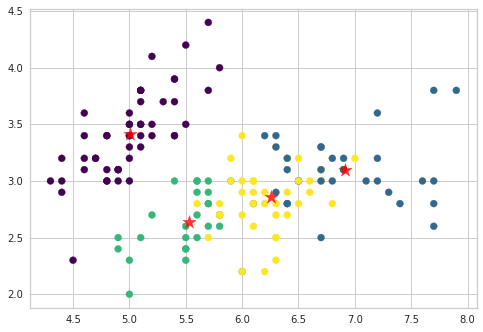

In [6]:
Kcluster2DPlotter(work_data,4)

In [7]:
def Kcluster3DPlotter(df,n_clusters,fig_size=(16,9),random_state=42):
    kmeans=KMeans(n_clusters=n_clusters,random_state=random_state)
    kmeans.fit(df.values)
    for i in range (1,n_clusters+1):
        print('Cluster Center ',i,' coordinates: ',kmeans.cluster_centers_[i-1])
    fig=plt.figure(figsize=fig_size)
    ax=Axes3D(fig)
    ax.scatter(df.iloc[:,0],df.iloc[:,1],df.iloc[:,2],c=kmeans.labels_,cmap='viridis')
    for i in range (n_clusters):
        ax.scatter(kmeans.cluster_centers_[i][0],kmeans.cluster_centers_[i][1],kmeans.cluster_centers_[i][2],s=200,alpha=0.8,marker='*',c='red')
       

Cluster Center  1  coordinates:  [5.006 3.418 1.464 0.244]
Cluster Center  2  coordinates:  [6.9125   3.1      5.846875 2.13125 ]
Cluster Center  3  coordinates:  [5.53214286 2.63571429 3.96071429 1.22857143]
Cluster Center  4  coordinates:  [6.2525 2.855  4.815  1.625 ]


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:7: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  import sys


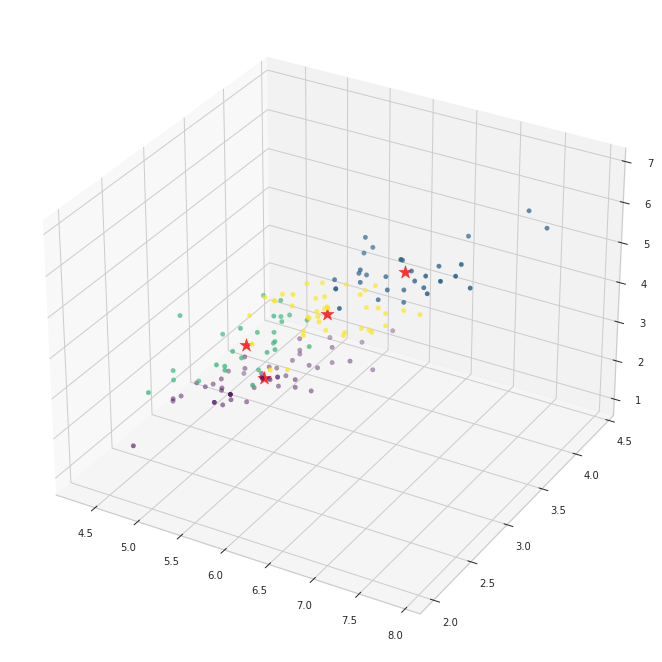

In [8]:
Kcluster3DPlotter(work_data,4)

# 2.1. Determining the Optimum K
To determine optimum number of clusters we will use Elbow Method: In this method,
1. We try the different number of clusters and score them based on a certain metric.
2. We plot these scores and the number of clusters to y and x-axis respectively then construct a curve from these plots. 
3. Finally, we detect the breaking point of the curve. The x projection of this point gives the optimum number of clusters.     

Metrics:

1. Distortion Score: Sum of squared distances from each point to its assigned center.
2. Silhouette: Scores based on the mean Silhouette Coefficient.
3. Calinski_harabasz: Computes dispersion between clusters divided by dispersion within the clusters and scores based on that.

In [9]:
def optimizer_graph(df,metric='distortion',upper_limit=10):
    
    visualizer=KElbowVisualizer(KMeans(),k=(2,upper_limit),timings=False,metric=metric)
    visualizer.fit(df)
    return visualizer.poof();

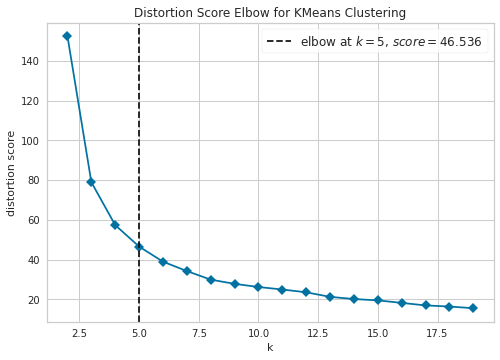

In [10]:
optimizer_graph(df=work_data,upper_limit=20);

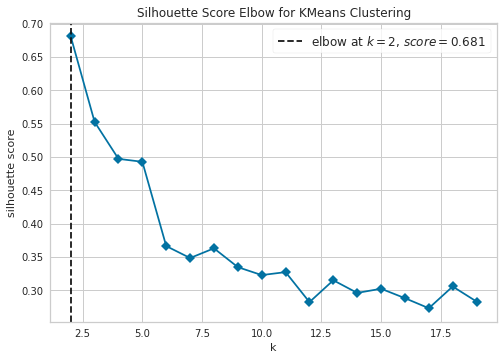

In [11]:
optimizer_graph(df=work_data,metric='silhouette' ,upper_limit=20);

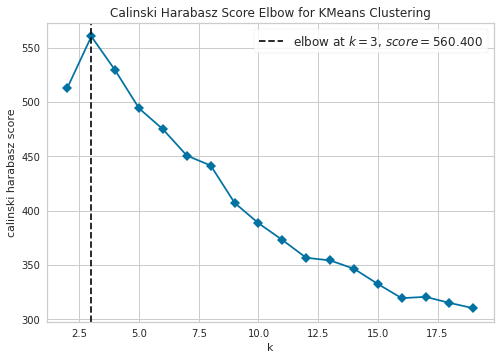

In [12]:
optimizer_graph(df=work_data,metric='calinski_harabasz' ,upper_limit=20);

# Appendix
## Dendrograms

In [13]:
def dendrogram_constructor(df,method='complete',look='all'):
    if look =='all':
        hyc=linkage(df,method)
        plt.figure(figsize=(16,9))
        plt.title(f'Complete Dendrogram with {method} method')
        plt.xlabel('Index')
        plt.ylabel('Distance')
        dendrogram(hyc,leaf_font_size=5);
    else:
        hyc=linkage(df,method)
        plt.figure(figsize=(16,9))
        plt.title(f'Dendrogram with {look} Clusters, ({method} Method)')
        plt.xlabel('Index')
        plt.ylabel('Distance')
        dendrogram(hyc,leaf_font_size=15,truncate_mode='lastp',p=look);

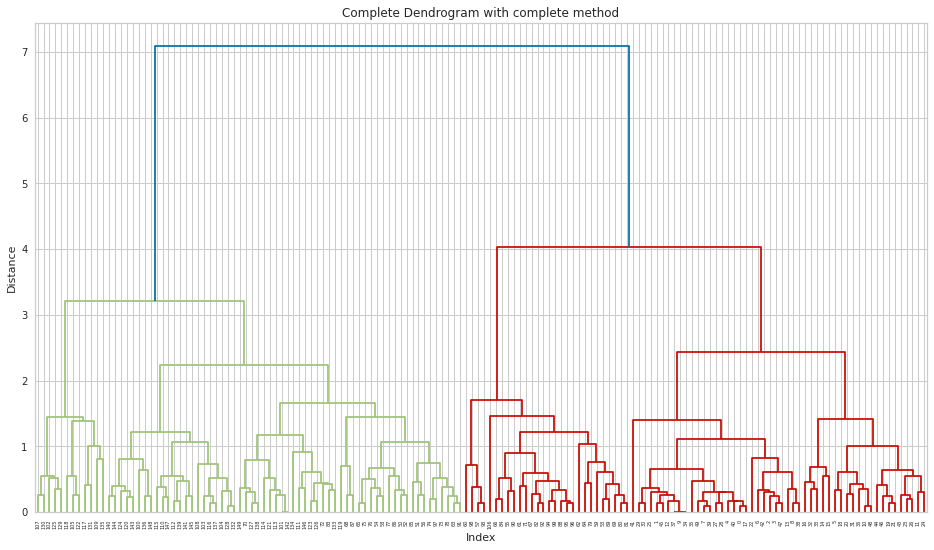

In [14]:
dendrogram_constructor(work_data)

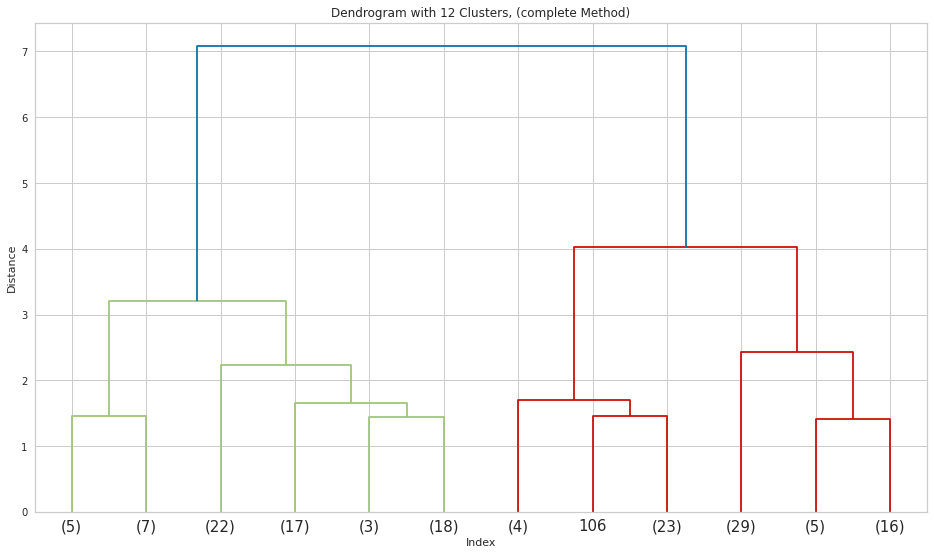

In [15]:
dendrogram_constructor(work_data,look=12)


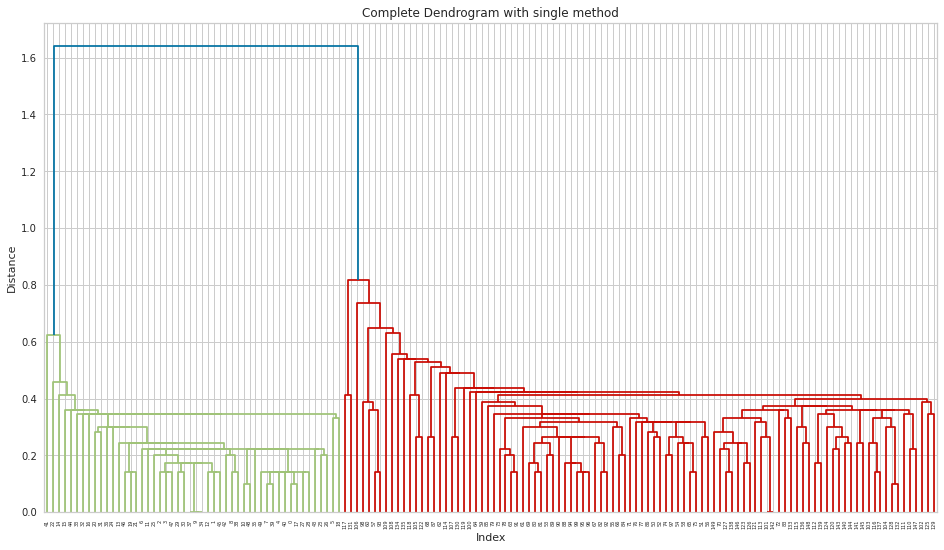

In [16]:
dendrogram_constructor(work_data,method='single')

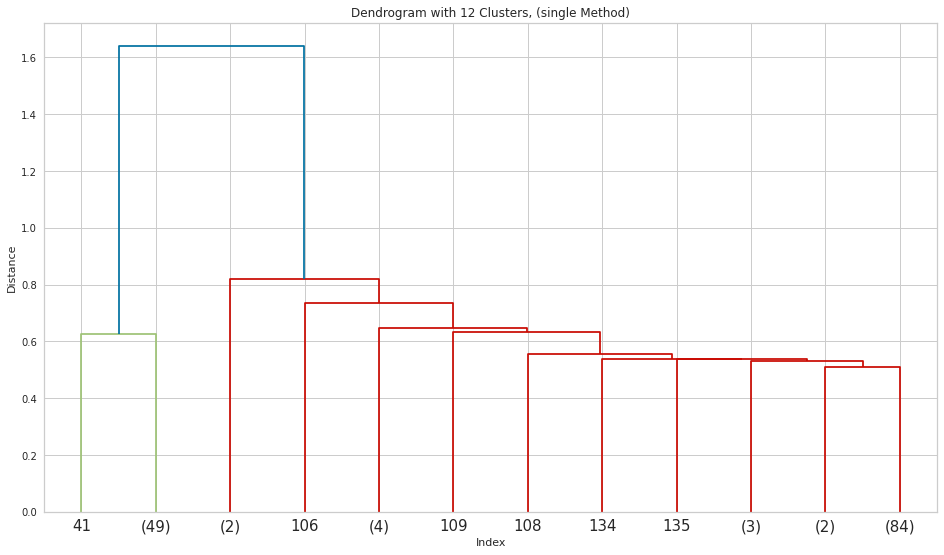

In [17]:
dendrogram_constructor(work_data,method='single',look=12)

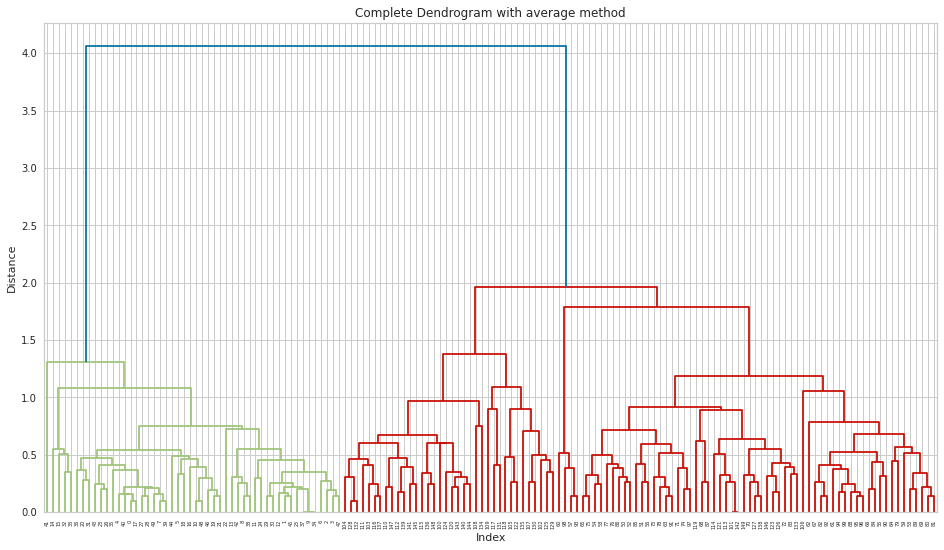

In [18]:
dendrogram_constructor(work_data,method='average')

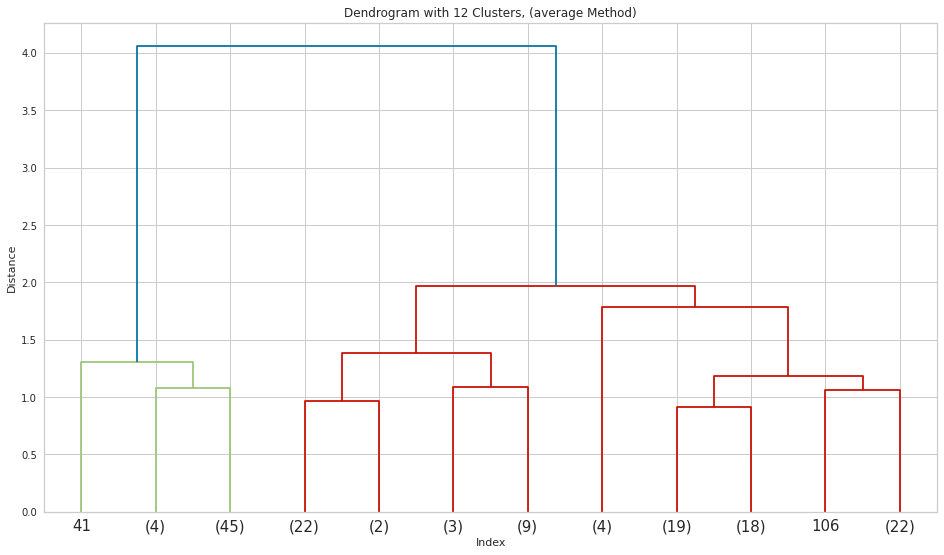

In [19]:
dendrogram_constructor(work_data,method='average',look=12)

Thanks...